In [31]:
# Turbofan Engine Predictive Maintenance EDA

# --- 1. Kütüphaneler ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os 
sns.set(style='whitegrid')



In [33]:
# --- 2. Veri Yükleme Fonksiyonu ---
def load_cmapss(file_path):
    cols = ['unit', 'cycle'] + [f'op{i}' for i in range(1,4)] + [f's{i}' for i in range(1,22)]
    df = pd.read_csv(file_path, sep='\s+', header=None, names=cols)
    return df

def add_rul_train(df):
    max_cycle = df.groupby('unit')['cycle'].max().reset_index().rename(columns={'cycle':'max_cycle'})
    df = df.merge(max_cycle, on='unit', how='left')
    df['RUL'] = df['max_cycle'] - df['cycle']
    df = df.drop(columns=['max_cycle'])
    return df

# --- Klasör oluştur ---
fig_dir = 'figures'
os.makedirs(fig_dir, exist_ok=True)

In [35]:
# --- 3. Veri Yükleme ---
train_path = 'data/train_FD001.txt'
train = load_cmapss(train_path)
train = add_rul_train(train)

print("Train shape:", train.shape)
train.head()


Train shape: (20631, 27)


,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [37]:

# --- 4. Temel İstatistikler ---
print("Columns:\n", train.columns.tolist())
print("\nBasic statistics:\n", train.describe())


Columns:
 ['unit', 'cycle', 'op1', 'op2', 'op3', 's1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21', 'RUL']

Basic statistics:
                unit         cycle           op1           op2      op3  \
count  20631.000000  20631.000000  20631.000000  20631.000000  20631.0   
mean      51.506568    108.807862     -0.000009      0.000002    100.0   
std       29.227633     68.880990      0.002187      0.000293      0.0   
min        1.000000      1.000000     -0.008700     -0.000600    100.0   
25%       26.000000     52.000000     -0.001500     -0.000200    100.0   
50%       52.000000    104.000000      0.000000      0.000000    100.0   
75%       77.000000    156.000000      0.001500      0.000300    100.0   
max      100.000000    362.000000      0.008700      0.000600    100.0   

                 s1            s2            s3            s4            s5  \
count  2.063100e+04  20631.000000  20631

In [39]:

# --- 5. Eksik Değer Kontrolü ---
print("\nMissing values:\n", train.isnull().sum())




Missing values:
 unit     0
cycle    0
op1      0
op2      0
op3      0
s1       0
s2       0
s3       0
s4       0
s5       0
s6       0
s7       0
s8       0
s9       0
s10      0
s11      0
s12      0
s13      0
s14      0
s15      0
s16      0
s17      0
s18      0
s19      0
s20      0
s21      0
RUL      0
dtype: int64


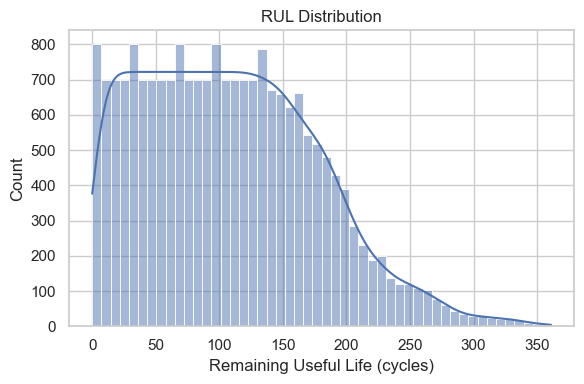

In [41]:
# --- 6. RUL Dağılımı ---
plt.figure(figsize=(6,4))
sns.histplot(train['RUL'], bins=50, kde=True)
plt.title("RUL Distribution")
plt.xlabel("Remaining Useful Life (cycles)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "rul_distribution.png"))
plt.show()


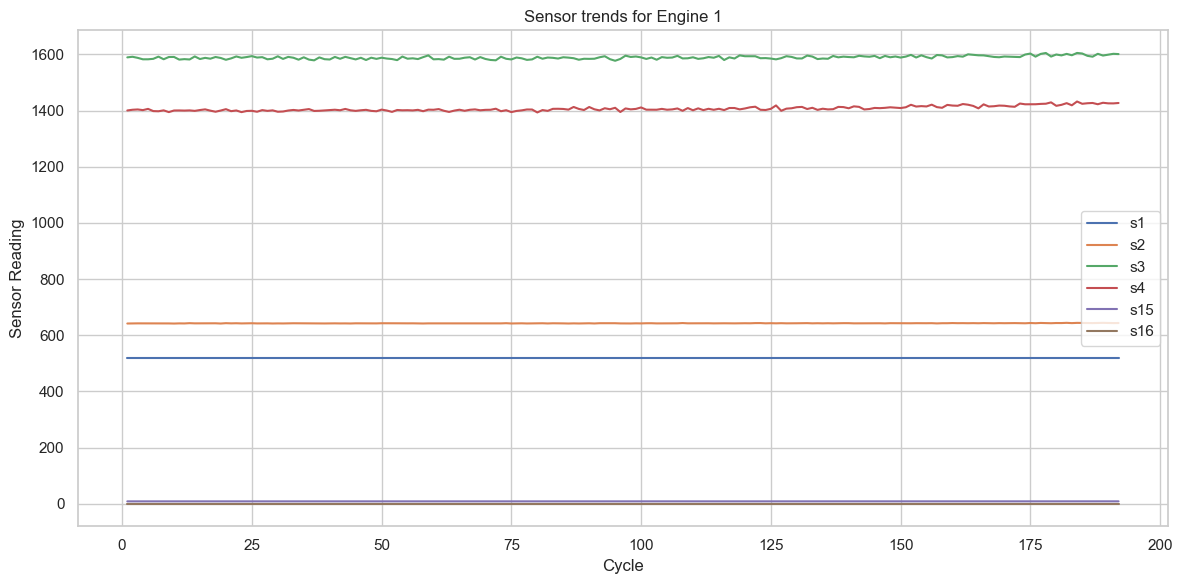

In [42]:
# --- 7. Bir Motorun Degradasyonunu Görselleştirme ---
plt.figure(figsize=(12,6))
for s in ['s1','s2','s3','s4','s15','s16']:
    plt.plot(unit_data['cycle'], unit_data[s], label=s)
plt.title(f"Sensor trends for Engine {unit_id}")
plt.xlabel("Cycle")
plt.ylabel("Sensor Reading")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, f"sensor_trends_unit{unit_id}.png"))
plt.show()


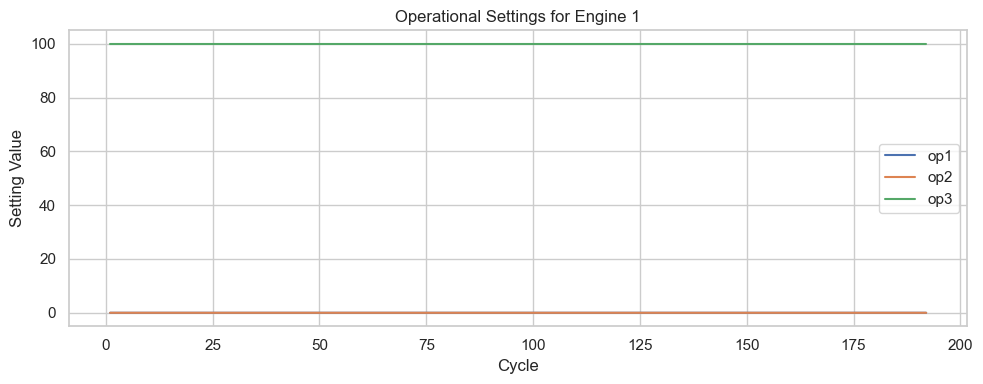

In [45]:
# --- 8. Operasyonel Ayarların İncelenmesi ---
plt.figure(figsize=(10,4))
for op in ['op1','op2','op3']:
    plt.plot(unit_data['cycle'], unit_data[op], label=op)
plt.title(f"Operational Settings for Engine {unit_id}")
plt.xlabel("Cycle")
plt.ylabel("Setting Value")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, f"operational_settings_unit{unit_id}.png"))
plt.show()

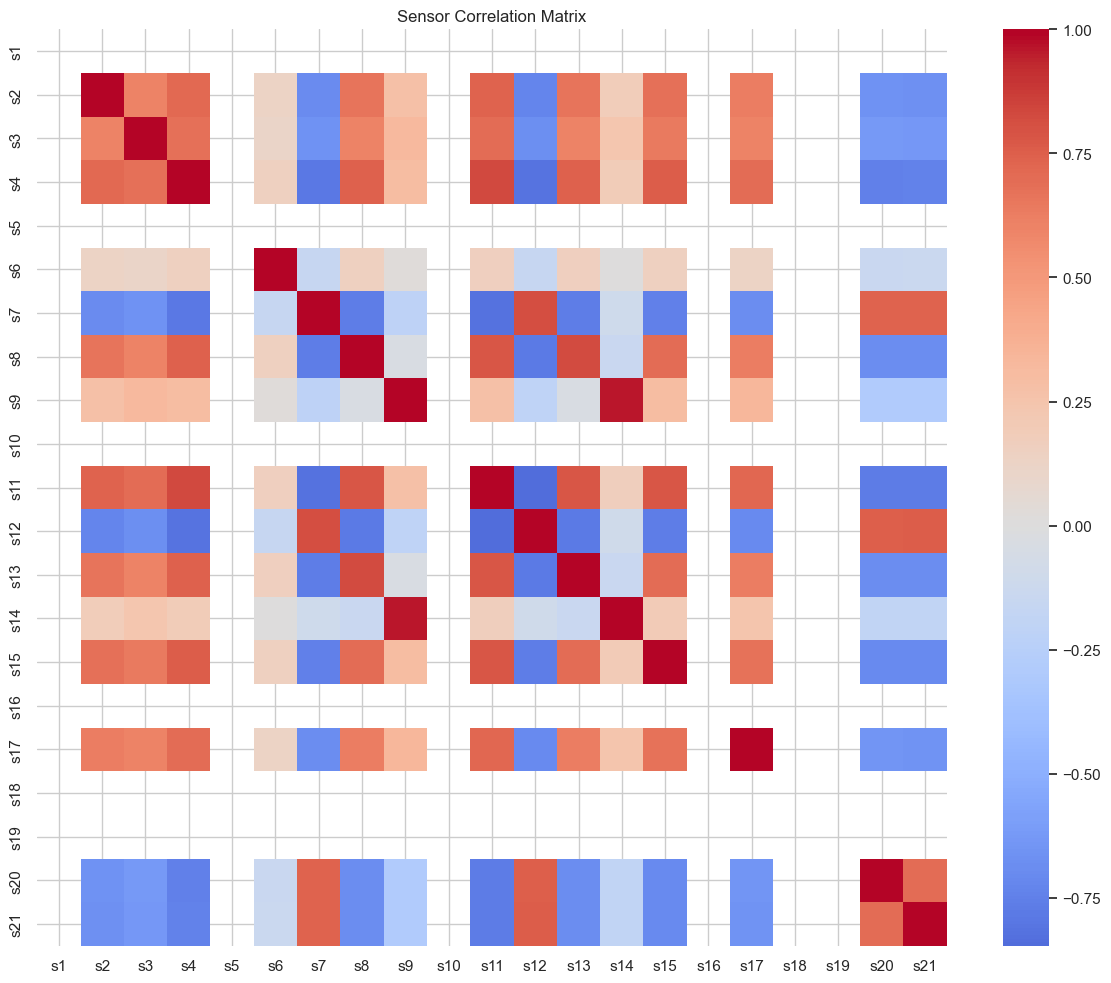

In [47]:
# --- 9. Korelasyon Matrisi ---
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title("Sensor Correlation Matrix")
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "sensor_correlation_matrix.png"))
plt.show()



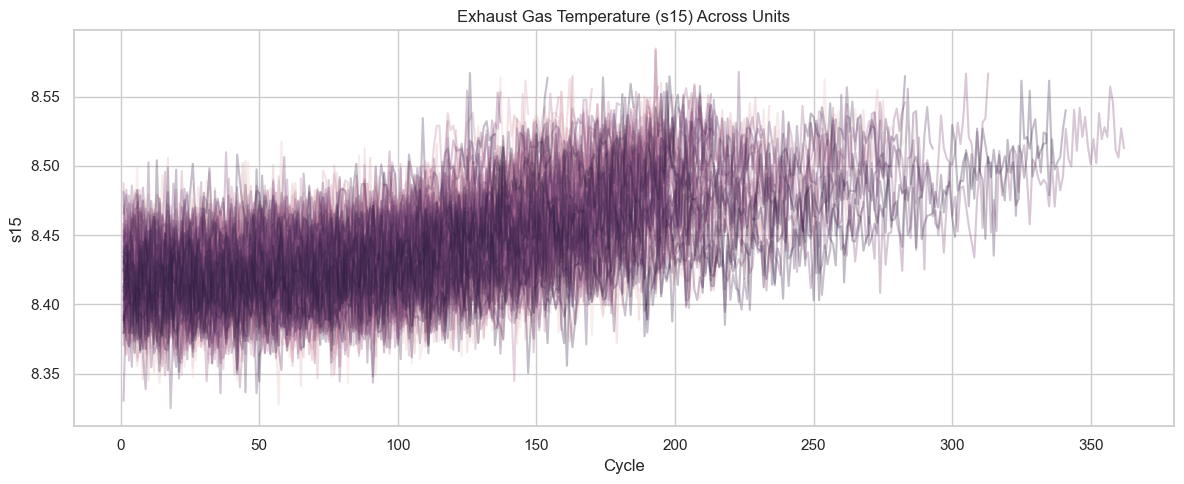

In [48]:
# --- 10. Önemli Sensorların RUL ile ilişkisi ---
plt.figure(figsize=(12,5))
sns.lineplot(data=train, x='cycle', y='s15', hue='unit', legend=False, alpha=0.3)
plt.title("Exhaust Gas Temperature (s15) Across Units")
plt.xlabel("Cycle")
plt.ylabel("s15")
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "s15_across_units.png"))
plt.show()

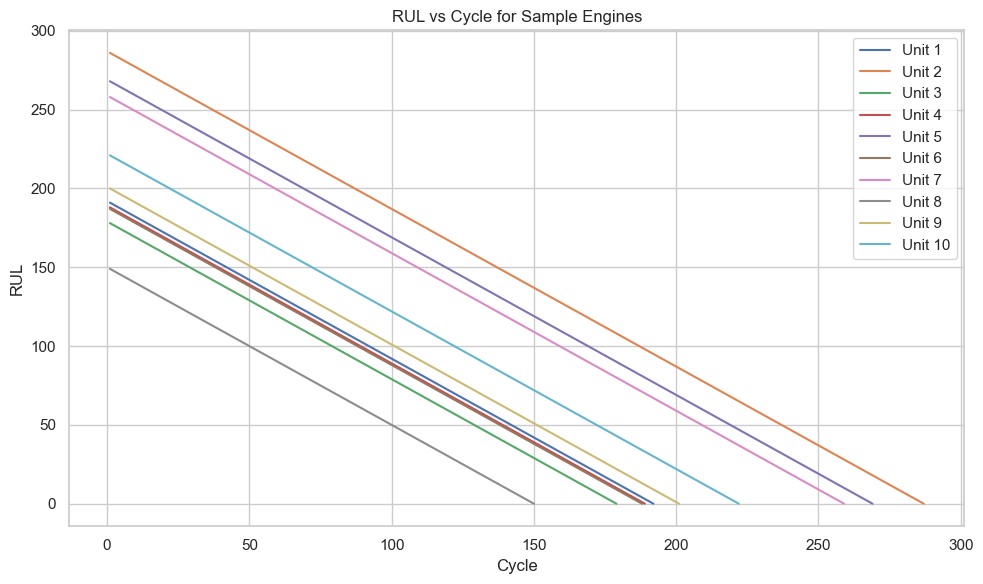

In [50]:
# --- 11. Çoklu Motorlar İçin RUL vs Cycle ---
plt.figure(figsize=(10,6))
sample_units = train['unit'].unique()[:10]
for uid in sample_units:
    plt.plot(train[train['unit']==uid]['cycle'], train[train['unit']==uid]['RUL'], label=f'Unit {uid}')
plt.title("RUL vs Cycle for Sample Engines")
plt.xlabel("Cycle")
plt.ylabel("RUL")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "rul_vs_cycle_sample_units.png"))
plt.show()


In [51]:
# --- 12. Özet ---
print("EDA completed. Next steps: feature engineering, rolling stats, normalization, sequence building for ML/DL.")


EDA completed. Next steps: feature engineering, rolling stats, normalization, sequence building for ML/DL.
